In [1]:
print("all ok")

all ok


In [2]:
model="meta-llama/llama-4-maverick-17b-128e-instruct"
from langchain_groq import ChatGroq
llm = ChatGroq(
    model_name=model,
    temperature=0
)
response=llm.invoke("what is length of wall of china?")

In [3]:
response

AIMessage(content="The Great Wall of China is approximately 13,171 miles (21,196 kilometers) long, according to the most recent measurements. However, it's worth noting that the exact length can vary depending on the source and method of measurement, as the wall is not a continuous structure and has many branches and sections.\n\nThe Great Wall of China is a series of fortifications built across several Chinese dynasties to protect the country from invasions. The wall stretches across mountains, valleys, and deserts, and its construction spanned many centuries, with the earliest versions of the wall being built as early as the 7th century BC.\n\nThe most famous and well-preserved sections of the wall were built during the Ming Dynasty (1368-1644), and it's these sections that are most commonly associated with the Great Wall of China. The wall was continuously fortified and extended over the centuries, with the most significant construction taking place during the Qin (221-206 BC), Han 

In [4]:
response.content

"The Great Wall of China is approximately 13,171 miles (21,196 kilometers) long, according to the most recent measurements. However, it's worth noting that the exact length can vary depending on the source and method of measurement, as the wall is not a continuous structure and has many branches and sections.\n\nThe Great Wall of China is a series of fortifications built across several Chinese dynasties to protect the country from invasions. The wall stretches across mountains, valleys, and deserts, and its construction spanned many centuries, with the earliest versions of the wall being built as early as the 7th century BC.\n\nThe most famous and well-preserved sections of the wall were built during the Ming Dynasty (1368-1644), and it's these sections that are most commonly associated with the Great Wall of China. The wall was continuously fortified and extended over the centuries, with the most significant construction taking place during the Qin (221-206 BC), Han (206 BC-220 AD), S

In [5]:
from langchain.tools import tool

## this is my custom tools

In [6]:
from langchain.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """
    Multiply two integers.

    Args:
        a (int): The first integer.
        b (int): The second integer.

    Returns:
        int: The product of a and b.
    """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """
    Add two integers.

    Args:
        a (int): The first integer.
        b (int): The second integer.

    Returns:
        int: The sum of a and b.
    """
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """
    Divide two integers.

    Args:
        a (int): The numerator.
        b (int): The denominator (must not be 0).

    Returns:
        float: The result of division.
    """
    if b == 0:
        raise ValueError("Denominator cannot be zero.")
    return a / b

## importing the inbuilt tool

In [7]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [8]:
search.invoke("what is the latest update on iphone17 release?")

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


"Breaking news from Hong Kong, China and Asia including geopolitics, diplomacy, economy, technology, lifestyle, entertainment and sport. Latest China news, opinions and analysis, covering Xi Jinping, Beijing's relations with Taiwan and China's tensions with the US. Latest Singapore news, including the city state’s relationships with Malaysia and Mahathir, China and Xi Jinping, and the rest of Southeast Asia. Latest Hong Kong news, updates, opinions and analysis, including on Hong Kong politics, the national security law, economy, society and weather. Horse racing news, fixtures, race reports, features and analysis."

In [ ]:
# !pip install duckduckgo_search


In [9]:
tools=[multiply, add, divide, search]

In [10]:
llm_with_tools=llm.bind_tools(tools)

In [11]:
response=llm_with_tools.invoke("hi")

In [12]:
response.content

'Hi! How can I assist you today?'

In [13]:
response.tool_calls

[]

In [14]:
response=llm_with_tools.invoke("what is 2+2?")

In [15]:
response.content

''

In [16]:
response.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'hvpvnncpq',
  'type': 'tool_call'}]

In [17]:
response=llm_with_tools.invoke("what is 10/2?")

In [18]:
response.content

''

In [19]:
response.tool_calls

[{'name': 'divide',
  'args': {'a': 10, 'b': 2},
  'id': '3bkrha5ym',
  'type': 'tool_call'}]

In [20]:
response=llm_with_tools.invoke("what is a current age of the TATA Group?")

In [21]:
response

AIMessage(content="To determine the current age of the TATA Group, we need to know its founding date. The TATA Group was founded on 29 July 1868 (as Tata Sons). Let's proceed to calculate its age.\n\nFirst, we need to get the current year. I'll use internal knowledge for this.\n\nThe current year is 2024. The TATA Group was founded in 1868. \n\nNow, let's calculate its age:\n2024 - 1868 = 156\n\nThe TATA Group is currently 156 years old.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 982, 'total_tokens': 1092, 'completion_time': 0.235668421, 'prompt_time': 0.024008218, 'queue_time': 0.052786782, 'total_time': 0.259676639}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--5fa61b69-e219-4cc0-bc6b-e39a486a03d2-0', usage_metadata={'input_tokens': 982, 'output_tokens': 110, 'total_tokens': 1092})

In [22]:
response.content

"To determine the current age of the TATA Group, we need to know its founding date. The TATA Group was founded on 29 July 1868 (as Tata Sons). Let's proceed to calculate its age.\n\nFirst, we need to get the current year. I'll use internal knowledge for this.\n\nThe current year is 2024. The TATA Group was founded in 1868. \n\nNow, let's calculate its age:\n2024 - 1868 = 156\n\nThe TATA Group is currently 156 years old."

In [23]:
response.tool_calls

[]

In [30]:
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [31]:
SYSTEM_PROMPT="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs."



In [32]:
user_query=["tell me what is 2+2"]

In [33]:
[SYSTEM_PROMPT]+user_query

['You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.',
 'tell me what is 2+2']

In [34]:
def function_1(state:MessagesState):
    
    user_question=state["messages"]
    
    input_question = [SYSTEM_PROMPT]+user_question
    
    response = llm_with_tools.invoke(input_question)
    
    return {
        "messages":[response]
    }
    
    

In [35]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START

In [36]:
builder=StateGraph(MessagesState)

In [37]:
builder.add_node("llm_decision_step",function_1)

In [38]:
tools

[StructuredTool(name='multiply', description='Multiply two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The product of a and b.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000002A61FABA2A0>),
 StructuredTool(name='add', description='Add two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The sum of a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x000002A60BC900E0>),
 StructuredTool(name='divide', description='Divide two integers.\n\nArgs:\n    a (int): The numerator.\n    b (int): The denominator (must not be 0).\n\nReturns:\n    float: The result of division.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x000002A60FF38FE0>),
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', 

In [39]:
from langgraph.prebuilt import ToolNode
builder.add_node("tools",ToolNode(tools))

<frozen abc>:106: LangGraphDeprecatedSinceV10: AgentStatePydantic has been moved to `langchain.agents`. Please update your import to `from langchain.agents import AgentStatePydantic`. Deprecated in LangGraph V1.0 to be removed in V2.0.


In [40]:
builder.add_edge(START,"llm_decision_step")

In [41]:
from langgraph.prebuilt import tools_condition
builder.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)


In [42]:
builder.add_edge("tools","llm_decision_step")

In [43]:
react_graph=builder.compile()

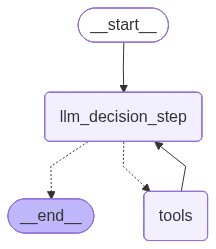

In [44]:
from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [45]:
message=[HumanMessage(content="What is 2 times of narendramodi's age?")]

In [46]:
react_graph.invoke({"messages":message})

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


{'messages': [HumanMessage(content="What is 2 times of narendramodi's age?", additional_kwargs={}, response_metadata={}, id='861ac784-d3a2-4571-9df7-8c474438c99d'),
  AIMessage(content="To determine the result, I'll first need to find Narendra Modi's age. I'll use the duckduckgo_search function to look up his age.\n\n", additional_kwargs={'tool_calls': [{'id': 'xmat1aaz5', 'function': {'arguments': '{"query":"Narendra Modi age"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 1007, 'total_tokens': 1071, 'completion_time': 0.102845998, 'prompt_time': 0.077150207, 'queue_time': 0.108308452, 'total_time': 0.179996205}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--d09dfc1f-8e07-44ae-9a5e-50111bf3394f-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': '

In [47]:
message = [HumanMessage(content="How much is the net worth of Elon Musk, and divide it by 2?")]

In [48]:
react_graph.invoke({"messages":message})

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


{'messages': [HumanMessage(content='How much is the net worth of Elon Musk, and divide it by 2?', additional_kwargs={}, response_metadata={}, id='708fa975-6970-4109-a858-de534b113d68'),
  AIMessage(content="To determine the result, I need to follow these steps:\n1. Find Elon Musk's net worth.\n2. Divide the net worth by 2.\n\nFirst, I will search for Elon Musk's net worth.\n\n", additional_kwargs={'tool_calls': [{'id': 'bk3rwm0kx', 'function': {'arguments': '{"query":"Elon Musk net worth"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 1011, 'total_tokens': 1089, 'completion_time': 0.114263522, 'prompt_time': 0.022487773, 'queue_time': 0.050678107, 'total_time': 0.136751295}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--b47a8cf0-70c3-4d7b-b01a-b0586b1a68a2-0',

In [49]:
message = [HumanMessage(content="What is the speed of light in m/s and multiply it by 10?")]

In [50]:
response=react_graph.invoke({"messages":message})

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


In [51]:
response["messages"][-1].content

'The speed of light is 299,792,458 m/s. When multiplied by 10, the result is 2,997,924,580.'

In [52]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the speed of light in m/s and multiply it by 10?
================================== Ai Message ==================================

To determine the result, I will first need to find the speed of light. Then, I will multiply it by 10.

First, let's find the speed of light.
Tool Calls:
  duckduckgo_search (x9bcc6eyh)
 Call ID: x9bcc6eyh
  Args:
    query: speed of light in m/s
================================= Tool Message =================================
Name: duckduckgo_search

Sep 29, 2020 · The speed of sound travels at around 343 m/s, while the speed of light travels at 299,792,458 m/s. In miles per hour/mph, the speed of light is at around 670,616,629, while in … Mar 17, 2020 · The speed of light’s exact value is defined as 299.792.458 meters per second or approximately 300.000 km / 186.000 mi per second in a vacuum. Oct 7, 2020 · The speed of light in a medium is 2.5 × 10 (8) m/s. What is it

In [53]:
import yfinance as yf

In [54]:
@tool
def get_stock_price(ticker:str)->str:
    """
    Fetches the previous closing price of a given stock ticker from Yahoo Finance.

    Args:
        ticker (str): The stock ticker symbol (e.g., 'AAPL', 'TSLA', 'NIFTY.BO').

    Returns:
        str: A message with the stock's previous closing price.
    """
    try:
        stock = yf.Ticker(ticker)
        price = stock.info.get('previousClose')
        if price is None:
            return f"Could not fetch price for ticker '{ticker}'."
        return f"The last closing price of {ticker.upper()} was ${price:.2f}."
    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"
     
    

In [55]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $259.58.'

In [56]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $448.98.'

In [57]:
tools

[StructuredTool(name='multiply', description='Multiply two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The product of a and b.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000002A61FABA2A0>),
 StructuredTool(name='add', description='Add two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The sum of a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x000002A60BC900E0>),
 StructuredTool(name='divide', description='Divide two integers.\n\nArgs:\n    a (int): The numerator.\n    b (int): The denominator (must not be 0).\n\nReturns:\n    float: The result of division.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x000002A60FF38FE0>),
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', 

In [58]:
tools = [add, multiply, divide, search,get_stock_price]

In [59]:
llm_with_tools=llm.bind_tools(tools)

In [60]:
response=llm_with_tools.invoke("can you give me a latest stock price of adani greens?")

In [61]:
response.content

''

In [62]:
response.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'ADANIGREEN.NS'},
  'id': 'sb36aw5zm',
  'type': 'tool_call'}]

In [63]:
SYSTEM_PROMPT = SystemMessage(
    content="You are a helpful assistant tasked with using search, the yahoo finance tool and performing arithmetic on a set of inputs."
)
def function_1(state:MessagesState):
    
    user_question=state["messages"]
    
    input_question = [SYSTEM_PROMPT]+user_question
    
    response = llm_with_tools.invoke(input_question)
    
    return {
        "messages":[response]
    }

In [64]:
workflow = StateGraph(MessagesState)
workflow.add_node("llm_decision_step", function_1)
workflow.add_node("tools", ToolNode(tools))
workflow.add_edge(START, "llm_decision_step")
workflow.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)
workflow.add_edge("tools", "llm_decision_step")
react_graph2 = workflow.compile()

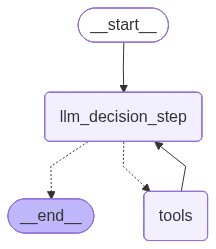

In [65]:
display(Image(react_graph2.get_graph(xray=True).draw_mermaid_png()))

In [69]:
messages = [HumanMessage(content="can you give me 2 times of current stock price of Apple with the latest news of the Apple.")]
messages = react_graph2.invoke({"messages": messages})

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


In [70]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

can you give me 2 times of current stock price of Apple with the latest news of the Apple.
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (z83y9ab48)
 Call ID: z83y9ab48
  Args:
    ticker: AAPL
  duckduckgo_search (73vqrqtgj)
 Call ID: 73vqrqtgj
  Args:
    query: Apple latest news
================================= Tool Message =================================
Name: get_stock_price

The last closing price of AAPL was $259.58.
================================= Tool Message =================================
Name: duckduckgo_search

No good DuckDuckGo Search Result was found
================================== Ai Message ==================================

The last closing price of AAPL was $259.58. Unfortunately, I was unable to retrieve the latest news about Apple.


In [ ]:
Assignment:
    
AI Travel Agent & Expense Planner(Purpose: Trip planning for any city worldwide with Realtime data.")

• Real-time weather information
• Top attractions and activities
• Hotel cost calculation (per day × total days)
• Currency conversion to user's native currency
• Complete itinerary generation
• Total expense calculation
• generate a summary of the entire output

user_input
  |
search attraction and activity
1. search attracation
2. search restaurant
3. search activity
4. search transportation
  |
search weather forcasting
1. get current weather
2. get weather forcast
  |
search hotel costs
1. search hotel
2. estimate the hotel cost
3. budget_range
  |
calculate total cost
1. add
2. multiply
3. calculated total cost
4. calcualte the daily budget
    | 
currency_converion
1. get exchnage rate
2. convert currancy
    | 
Itinery generation
1. get day plan
2. crete full itinery
    |
create Trip Summary
    |
Retun complete traval plan

Note: if you know the OOPS then design this entire system using object and class in modular fashion.


deadline is till next friday 9PM IST


 everyone you can submit the assignments in this form. MAke sure to have one GitHub link and put all the assignments there https://forms.gle/g8RZ4qx8yvNcih4B7    
    